============================================================
 VoltRide — Financial Calculations + Visualizations 
------------------------------------------------------------
What this notebook does (end-to-end):
1) Loads VoltRide Excel (rides + optional charging sheet)
2) Computes core financial metrics:
    - requests / completed / cancelled + cancellation rate
    - potential GMV (fare * surge), realized GMV, lost GMV (proxy)
    - avg GMV per completed vs cancelled ride
    - surge uplift (fare * (surge-1)) and its share of GMV
    - city-wise GMV + loss
    - cancellation-by decomposition (if column exists)
    - driver unavailable "hard fail" (if column exists)
    - battery band impact (conversion + loss)
    - zone-hour hotspots
    - platform revenue scenarios (take rate)
3) Makes multiple charts for quick visual analysis
 Important:
- Nothing is saved to disk.
- Includes a robust fix for: TypeError: unhashable type: 'numpy.ndarray'
  (battery plot uses matplotlib and hard-sanitizes labels)
============================================================


In [8]:

import os
import re
import warnings
from typing import Optional, List, Any

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

DATA_PATH = "DecodeX_VoltRide_Dataset.xlsx"  # <-- update if needed


# ----------------------------
# Small utilities
# ----------------------------
def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase + snake_case column names."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )
    return df

def pick_first_matching(colnames: List[str], candidates: List[str]) -> Optional[str]:
    s = set(colnames)
    for c in candidates:
        if c in s:
            return c
    return None

def pick_fuzzy(colnames: List[str], patterns: List[str]) -> Optional[str]:
    for p in patterns:
        rgx = re.compile(p)
        for c in colnames:
            if rgx.search(c):
                return c
    return None

def ensure_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def safe_div(a, b):
    a = np.asarray(a, dtype="float64")
    b = np.asarray(b, dtype="float64")
    return np.where(b == 0, np.nan, a / b)

def normalize_outcome(x: Any) -> str:
    """Normalize different status/outcome spellings."""
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().lower()

    if "complete" in s or s in {"completed", "done", "finished", "success", "successful"}:
        return "Completed"
    if "cancel" in s or s in {"cancelled", "canceled", "cancel"}:
        return "Cancelled"
    if "fail" in s or "timeout" in s or "no_driver" in s:
        return "Failed"
    return str(x).strip()

def show(df: pd.DataFrame, title: Optional[str] = None, n: int = 10):
    if title:
        print(f"\n=== {title} ===")
    display(df.head(n))

# --- Hard sanitizer to prevent seaborn/pandas "unhashable numpy.ndarray" ---
def to_scalar_str(x: Any) -> Any:
    """
    Convert any ndarray/list/tuple/set (even nested singletons) into a scalar string.
    This prevents TypeError: unhashable type: 'numpy.ndarray' inside seaborn/pandas unique().
    """
    # unwrap nested singleton arrays/lists repeatedly
    while isinstance(x, np.ndarray) and x.size == 1:
        try:
            x = x.item()
        except Exception:
            break

    while isinstance(x, (list, tuple)) and len(x) == 1:
        x = x[0]

    if isinstance(x, np.ndarray):
        try:
            return ",".join(map(str, x.ravel().tolist()))
        except Exception:
            return str(x)

    if isinstance(x, (list, tuple, set)):
        try:
            return ",".join(map(str, list(x)))
        except Exception:
            return str(x)

    return x

def force_hashable_series(s: pd.Series) -> pd.Series:
    out = s.map(to_scalar_str)
    out = out.where(out.isna(), out.astype(str))  # keep NaN, stringify everything else
    return out


# ----------------------------
# Load Excel
# ----------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Excel file not found: {DATA_PATH}")

xls = pd.ExcelFile(DATA_PATH)
sheet_names = xls.sheet_names
print("Sheets found:", sheet_names)

def guess_sheet(names: List[str], keywords: List[str]) -> Optional[str]:
    for nm in names:
        low = nm.lower()
        if any(k in low for k in keywords):
            return nm
    return None

SHEET_RIDES = guess_sheet(sheet_names, ["ride", "trip", "booking", "request", "transaction"]) or sheet_names[0]
SHEET_CHARGING = guess_sheet(sheet_names, ["charg", "station", "queue", "wait"])

print("\nAuto-selected:")
print("  rides   :", SHEET_RIDES)
print("  charging:", SHEET_CHARGING)

rides = normalize_cols(pd.read_excel(DATA_PATH, sheet_name=SHEET_RIDES))

charging = None
if SHEET_CHARGING:
    try:
        charging = normalize_cols(pd.read_excel(DATA_PATH, sheet_name=SHEET_CHARGING))
    except Exception as e:
        print("Charging sheet load failed:", e)

print("\nRIDES columns:", list(rides.columns))
if charging is not None:
    print("CHARGING columns:", list(charging.columns))


# ----------------------------
# Column detection
# ----------------------------
cols = list(rides.columns)

col_outcome = (
    pick_first_matching(cols, ["ride_outcome", "outcome", "status", "trip_status", "request_status"])
    or pick_fuzzy(cols, [r"outcome", r"status"])
)
col_fare = (
    pick_first_matching(cols, ["estimated_fare", "fare", "base_fare", "trip_fare", "price", "amount"])
    or pick_fuzzy(cols, [r"fare", r"price", r"amount"])
)
col_surge = (
    pick_first_matching(cols, ["surge_multiplier", "surge", "multiplier"])
    or pick_fuzzy(cols, [r"surge", r"multiplier"])
)

col_city = pick_first_matching(cols, ["city"]) or pick_fuzzy(cols, [r"city"])
col_zone = (
    pick_first_matching(cols, ["pickup_zone", "zone", "service_zone", "area", "pickup_area"])
    or pick_fuzzy(cols, [r"zone", r"area"])
)
col_hour = pick_first_matching(cols, ["hour", "request_hour", "trip_hour", "time_hour"]) or pick_fuzzy(cols, [r"hour"])
col_date = pick_first_matching(cols, ["date", "request_date", "trip_date", "day"]) or pick_fuzzy(cols, [r"date", r"day"])

col_weather = (
    pick_first_matching(cols, ["weather", "rain", "rainfall", "precipitation"])
    or pick_fuzzy(cols, [r"weather", r"rain", r"precip"])
)
col_battery = pick_first_matching(cols, ["battery_level", "battery", "soc"]) or pick_fuzzy(cols, [r"battery", r"soc"])
col_driver_avail = (
    pick_first_matching(cols, ["driver_availability", "online_drivers", "available_drivers", "drivers_online"])
    or pick_fuzzy(cols, [r"drivers_online", r"online_driver", r"available_driver", r"driver"])
)

col_cancel_by = (
    pick_first_matching(cols, ["cancellation_by", "cancelled_by", "cancel_by", "cancel_by_who"])
    or pick_fuzzy(cols, [r"cancell.*by", r"cancel.*by", r"cancel_reason", r"reason"])
)
col_driver_available_flag = (
    pick_first_matching(cols, ["driver_available", "driver_avail", "is_driver_available"])
    or pick_fuzzy(cols, [r"driver_?available", r"is_?driver_?available", r"available_?flag"])
)

print("\nDetected columns:")
print("  outcome:", col_outcome)
print("  fare   :", col_fare)
print("  surge  :", col_surge)
print("  city   :", col_city)
print("  zone   :", col_zone)
print("  hour   :", col_hour)
print("  date   :", col_date)
print("  weather:", col_weather)
print("  battery:", col_battery)
print("  drivers (numeric):", col_driver_avail)
print("  cancellation_by  :", col_cancel_by)
print("  driver_available :", col_driver_available_flag)

if col_outcome is None or col_fare is None:
    raise ValueError("Required columns missing: outcome/status and fare/price.")



Sheets found: ['Ride_Level_Data', 'Driver_Data', 'Zone_Hour_Demand', 'Charging_Stations']

Auto-selected:
  rides   : Ride_Level_Data
  charging: Charging_Stations

RIDES columns: ['ride_id', 'city', 'date', 'hour', 'pickup_zone', 'drop_zone', 'ride_distance_km', 'estimated_fare', 'surge_multiplier', 'ev_battery_', 'driver_available', 'charging_station_nearby', 'weather', 'ride_status', 'cancellation_by']
CHARGING columns: ['station_id', 'city', 'zone', 'chargers_available', 'avg_wait_time_min']

Detected columns:
  outcome: ride_status
  fare   : estimated_fare
  surge  : surge_multiplier
  city   : city
  zone   : pickup_zone
  hour   : hour
  date   : date
  weather: weather
  battery: ev_battery_
  drivers (numeric): driver_available
  cancellation_by  : cancellation_by
  driver_available : driver_available


Feature engineering / numeric fields

In [9]:

rides = rides.copy()

rides["outcome_norm"] = rides[col_outcome].apply(normalize_outcome)
rides["fare_num"] = ensure_numeric(rides[col_fare])

if col_surge is None:
    rides["surge_num"] = 1.0
else:
    rides["surge_num"] = ensure_numeric(rides[col_surge]).fillna(1.0)
    rides.loc[rides["surge_num"] <= 0, "surge_num"] = 1.0

rides["effective_fare"] = rides["fare_num"] * rides["surge_num"]
rides["is_surge"] = (rides["surge_num"] > 1).astype(int)

# hour_num
if col_hour is not None:
    hour_numeric = pd.to_numeric(rides[col_hour], errors="coerce")
    if hour_numeric.notna().mean() > 0.7:
        rides["hour_num"] = hour_numeric.astype("Int64")
    else:
        dt = pd.to_datetime(rides[col_hour], errors="coerce")
        rides["hour_num"] = dt.dt.hour.astype("Int64")
else:
    rides["hour_num"] = pd.NA

# date_parsed
rides["date_parsed"] = pd.to_datetime(rides[col_date], errors="coerce") if col_date else pd.NaT

# rain flag (optional)
rides["rain_flag"] = np.nan
if col_weather is not None:
    w = rides[col_weather]
    if pd.to_numeric(w, errors="coerce").notna().mean() > 0.7:
        wn = pd.to_numeric(w, errors="coerce").fillna(0)
        rides["rain_flag"] = (wn > 0).astype(int)
    else:
        ws = w.astype(str).str.lower()
        rides["rain_flag"] = ws.str.contains("rain|drizzle|storm|shower|wet").astype(int)

# battery bands (use ASCII hyphen labels)
BATTERY_ORDER = ["<20%", "20-39%", "40-59%", "60-79%", "80%+"]

if col_battery is not None:
    rides["battery_num"] = ensure_numeric(rides[col_battery])
    rides["battery_band_label"] = pd.cut(
        rides["battery_num"],
        bins=[-np.inf, 20, 40, 60, 80, np.inf],
        labels=BATTERY_ORDER,
        include_lowest=True,
        right=False
    ).astype("object")
    rides["battery_band_label"] = force_hashable_series(rides["battery_band_label"])
else:
    rides["battery_num"] = np.nan
    rides["battery_band_label"] = np.nan

# drivers online (optional)
rides["drivers_online"] = ensure_numeric(rides[col_driver_avail]) if col_driver_avail else np.nan

# surge uplift
rides["surge_uplift"] = rides["fare_num"] * (rides["surge_num"] - 1)
rides.loc[rides["surge_uplift"] < 0, "surge_uplift"] = 0


# ----------------------------
# Core financial metrics
# ----------------------------
completed_mask = rides["outcome_norm"].eq("Completed")
cancelled_mask = rides["outcome_norm"].eq("Cancelled")

total_requests = len(rides)
completed_rides = int(completed_mask.sum())
cancelled_rides = int(cancelled_mask.sum())
cancel_rate = cancelled_rides / total_requests if total_requests else np.nan

requested_gmv = rides["effective_fare"].sum(skipna=True)  # potential GMV
completed_gmv = rides.loc[completed_mask, "effective_fare"].sum(skipna=True)
lost_gmv_proxy = requested_gmv - completed_gmv

avg_gmv_completed = rides.loc[completed_mask, "effective_fare"].mean()
avg_gmv_cancelled = rides.loc[cancelled_mask, "effective_fare"].mean()

surge_uplift_completed = rides.loc[completed_mask, "surge_uplift"].sum(skipna=True)
surge_uplift_share = surge_uplift_completed / completed_gmv if completed_gmv else np.nan

overall_kpis = pd.DataFrame({
    "Metric": [
        "Total Requests",
        "Completed",
        "Cancelled",
        "Cancellation Rate",
        "Potential GMV (Σ fare×surge)",
        "Realized GMV (Completed)",
        "Lost GMV from cancellations (Proxy)",
        "Avg GMV per completed ride",
        "Avg GMV per cancelled ride (lost)",
        "Surge uplift on completed rides (Σ fare×(surge−1))",
        "Surge uplift share of completed GMV",
    ],
    "Value": [
        total_requests,
        completed_rides,
        cancelled_rides,
        cancel_rate,
        requested_gmv,
        completed_gmv,
        lost_gmv_proxy,
        avg_gmv_completed,
        avg_gmv_cancelled,
        surge_uplift_completed,
        surge_uplift_share,
    ]
})




# Insights


In [10]:


# ----------------------------
# City-wise breakdown
# ----------------------------
city_fin = None
if col_city is not None:
    city_fin = rides.groupby(col_city, dropna=False).apply(
        lambda df: pd.Series({
            "Requests": len(df),
            "Completed": (df["outcome_norm"] == "Completed").sum(),
            "Cancelled": (df["outcome_norm"] == "Cancelled").sum(),
            "Cancel_%": safe_div((df["outcome_norm"] == "Cancelled").sum(), len(df)),
            "Completed_GMV": df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
            "Lost_GMV": df["effective_fare"].sum() - df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
        })
    ).reset_index().sort_values("Lost_GMV", ascending=False)
    show(city_fin, "CITY-WISE FINANCIAL BREAKDOWN", n=50)


# ----------------------------
# Cancellation_by decomposition 
# ----------------------------
cancel_decomp = None
if col_cancel_by is not None:
    rides[col_cancel_by] = force_hashable_series(rides[col_cancel_by])
    cancel_decomp = rides.loc[cancelled_mask].groupby(col_cancel_by, dropna=False).agg(
        Cancelled_Rides=("effective_fare", "size"),
        Lost_GMV=("effective_fare", "sum")
    ).reset_index()
    cancel_decomp["Share_of_Cancels"] = cancel_decomp["Cancelled_Rides"] / cancel_decomp["Cancelled_Rides"].sum()
    cancel_decomp["Share_of_Lost_GMV"] = cancel_decomp["Lost_GMV"] / cancel_decomp["Lost_GMV"].sum()
    show(cancel_decomp.sort_values("Lost_GMV", ascending=False),
         "LOST GMV DECOMPOSITION BY CANCELLATION_BY", n=50)
else:
    print("\nNo cancellation_by / reason column detected; skipping cancellation decomposition.")


# ----------------------------
# Hard fail: Driver_Available = No
# ----------------------------
hard_fail_summary = None
if col_driver_available_flag is not None:
    s = rides[col_driver_available_flag].astype(str).str.strip().str.lower()
    driver_no = s.isin(["no", "n", "false", "0"]) | s.str.contains(r"\bno\b|\bfalse\b", regex=True)

    hard_fail = rides.loc[driver_no].copy()
    hard_fail_summary = pd.DataFrame([{
        "Requests_when_driver_available_NO": len(hard_fail),
        "Cancelled_when_driver_available_NO": int((hard_fail["outcome_norm"] == "Cancelled").sum()),
        "Lost_GMV_when_driver_available_NO": hard_fail["effective_fare"].sum(),
        "Share_of_total_Lost_GMV_proxy": (hard_fail["effective_fare"].sum() / lost_gmv_proxy) if lost_gmv_proxy else np.nan
    }])
    show(hard_fail_summary, "HARD FAIL: DRIVER_AVAILABLE = NO", n=10)
else:
    print("\nNo driver_available flag column detected; skipping hard fail analysis.")


# ----------------------------
# Zone-hour hotspots 
# ----------------------------
zone_hour_fin = None
group_keys = []
if col_city is not None:
    group_keys.append(col_city)
if col_zone is not None:
    group_keys.append(col_zone)
if "hour_num" in rides.columns and rides["hour_num"].notna().any():
    group_keys.append("hour_num")

if group_keys:
    zone_hour_fin = rides.groupby(group_keys, dropna=False).apply(
        lambda df: pd.Series({
            "Requests": len(df),
            "Requested_GMV": df["effective_fare"].sum(),
            "Completed_Rides": (df["outcome_norm"] == "Completed").sum(),
            "Completed_GMV": df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
            "Avg_Surge": df["surge_num"].mean(),
            "Surge_Penetration": (df["surge_num"] > 1).mean(),
            "Avg_Drivers_Online": df["drivers_online"].mean(),
        })
    ).reset_index()

    zone_hour_fin["Lost_GMV"] = zone_hour_fin["Requested_GMV"] - zone_hour_fin["Completed_GMV"]
    zone_hour_fin["Cancel_Rate"] = 1 - safe_div(zone_hour_fin["Completed_Rides"], zone_hour_fin["Requests"])
    zone_hour_fin["GMV_Leakage_Rate"] = 1 - safe_div(zone_hour_fin["Completed_GMV"], zone_hour_fin["Requested_GMV"])
    zone_hour_fin["GMV_per_OnlineDriver"] = safe_div(zone_hour_fin["Completed_GMV"], zone_hour_fin["Avg_Drivers_Online"])
    zone_hour_fin["Requests_per_OnlineDriver"] = safe_div(zone_hour_fin["Requests"], zone_hour_fin["Avg_Drivers_Online"])
    zone_hour_fin["Financial_Stress_Index"] = zone_hour_fin["Requests_per_OnlineDriver"] * zone_hour_fin["GMV_Leakage_Rate"]

    show(zone_hour_fin.sort_values("Lost_GMV", ascending=False), "TOP ZONE-HOURS BY LOST_GMV", n=20)
    show(zone_hour_fin.sort_values("Financial_Stress_Index", ascending=False), "TOP ZONE-HOURS BY STRESS INDEX", n=20)
else:
    print("\nZone-hour analysis skipped: need at least one of city/zone/hour.")


# ----------------------------
# Battery band impact (safe)
# ----------------------------
batt_fin = None
if col_battery is not None and rides["battery_band_label"].notna().any():
    batt_fin = rides.groupby("battery_band_label", dropna=False).apply(
        lambda df: pd.Series({
            "Requests": len(df),
            "Cancelled": (df["outcome_norm"] == "Cancelled").sum(),
            "Cancel_%": safe_div((df["outcome_norm"] == "Cancelled").sum(), len(df)),
            "Completed_GMV": df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
            "Lost_GMV": df["effective_fare"].sum() - df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
        })
    ).reset_index().rename(columns={"battery_band_label": "battery_band"})

    batt_fin["battery_band"] = force_hashable_series(batt_fin["battery_band"])
    batt_fin = batt_fin[batt_fin["battery_band"].isin(BATTERY_ORDER)].copy()
    batt_fin["battery_band"] = pd.Categorical(batt_fin["battery_band"], categories=BATTERY_ORDER, ordered=True)
    batt_fin = batt_fin.sort_values("battery_band")

    show(batt_fin, "BATTERY BAND IMPACT (MONEY)", n=50)


# ----------------------------
# Surge vs non-surge summary
# ----------------------------
surge_summary = rides.groupby("is_surge").apply(
    lambda df: pd.Series({
        "Requests": len(df),
        "Requested_GMV": df["effective_fare"].sum(),
        "Completed_Rides": (df["outcome_norm"] == "Completed").sum(),
        "Completed_GMV": df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
        "Avg_Surge": df["surge_num"].mean(),
        "Avg_Effective_Fare": df["effective_fare"].mean(),
    })
).reset_index()

surge_summary["Ride_Conversion"] = safe_div(surge_summary["Completed_Rides"], surge_summary["Requests"])
surge_summary["GMV_Conversion"] = safe_div(surge_summary["Completed_GMV"], surge_summary["Requested_GMV"])
surge_summary["Leakage_Rate"] = 1 - surge_summary["GMV_Conversion"]
show(surge_summary, "SURGE VS NON-SURGE FINANCIAL SUMMARY", n=10)


# ----------------------------
# Platform revenue scenarios
# ----------------------------
take_rates = [0.20, 0.25, 0.30]
platform_revenue = pd.DataFrame([{
    "Take_Rate": t,
    "Platform_Revenue_on_Completed": completed_gmv * t,
    "Platform_Revenue_Lost_to_Cancels": lost_gmv_proxy * t
} for t in take_rates])
show(platform_revenue, "PLATFORM REVENUE SCENARIOS (TAKE RATE)", n=10)


# ----------------------------
# Charging congestion + SAFE MERGE (optional)
# ----------------------------
charging_agg = None
merged_hotspots = None

if charging is not None:
    ccols = list(charging.columns)
    c_city = pick_first_matching(ccols, ["city"]) or pick_fuzzy(ccols, [r"city"])
    c_zone = pick_first_matching(ccols, ["zone", "service_zone", "area", "pickup_zone"]) or pick_fuzzy(ccols, [r"zone", r"area"])
    c_hour = pick_first_matching(ccols, ["hour", "time_hour", "request_hour", "time"]) or pick_fuzzy(ccols, [r"hour", r"time"])
    c_wait = pick_first_matching(ccols, ["avg_wait_time", "wait_time", "average_wait_time", "queue_time"]) or pick_fuzzy(ccols, [r"wait", r"queue"])
    c_chargers = pick_first_matching(ccols, ["charger_count", "chargers", "num_chargers", "available_chargers"]) or pick_fuzzy(ccols, [r"charger", r"chargers"])

    print("\nCharging columns detected:")
    print("  city:", c_city)
    print("  zone:", c_zone)
    print("  hour:", c_hour)
    print("  wait:", c_wait)
    print("  chargers:", c_chargers)

    charging["avg_wait_time_num"] = ensure_numeric(charging[c_wait]) if c_wait and c_wait in charging.columns else np.nan
    charging["charger_count_num"] = ensure_numeric(charging[c_chargers]) if c_chargers and c_chargers in charging.columns else np.nan

    if c_hour and c_hour in charging.columns:
        hour_numeric = pd.to_numeric(charging[c_hour], errors="coerce")
        if hour_numeric.notna().mean() > 0.7:
            charging["hour_num"] = hour_numeric.astype("Int64")
        else:
            dt = pd.to_datetime(charging[c_hour], errors="coerce")
            charging["hour_num"] = dt.dt.hour.astype("Int64")
    else:
        charging["hour_num"] = pd.NA

    charging["wait_per_charger"] = safe_div(charging["avg_wait_time_num"], charging["charger_count_num"])

    ck = []
    if c_city is not None and c_city in charging.columns:
        ck.append(c_city)
    if c_zone is not None and c_zone in charging.columns:
        ck.append(c_zone)
    if charging["hour_num"].notna().any():
        ck.append("hour_num")

    if ck:
        charging_agg = charging.groupby(ck, dropna=False).agg(
            Avg_Wait_Time=("avg_wait_time_num", "mean"),
            Charger_Count=("charger_count_num", "mean"),
            Wait_per_Charger=("wait_per_charger", "mean"),
        ).reset_index()
        show(charging_agg.sort_values("Wait_per_Charger", ascending=False), "TOP CHARGING CONGESTION", n=20)

        if zone_hour_fin is not None:
            right = charging_agg.copy()

            rename_map = {}
            if c_city and col_city and c_city in right.columns and c_city != col_city:
                rename_map[c_city] = col_city
            if c_zone and col_zone and c_zone in right.columns and c_zone != col_zone:
                rename_map[c_zone] = col_zone
            right = right.rename(columns=rename_map)

            merge_keys = []
            if col_city and col_city in zone_hour_fin.columns and col_city in right.columns:
                merge_keys.append(col_city)
            if col_zone and col_zone in zone_hour_fin.columns and col_zone in right.columns:
                merge_keys.append(col_zone)
            if "hour_num" in zone_hour_fin.columns and "hour_num" in right.columns:
                merge_keys.append("hour_num")

            print("\nMerging zone-hour finance with charging on:", merge_keys)

            if merge_keys:
                merged_hotspots = zone_hour_fin.merge(right, on=merge_keys, how="left")
                merged_hotspots["LostGmv_x_WaitPerCharger"] = merged_hotspots["Lost_GMV"] * merged_hotspots["Wait_per_Charger"]
                show(merged_hotspots.sort_values("LostGmv_x_WaitPerCharger", ascending=False),
                     "TOP COMBINED HOTSPOTS (LOST_GMV * WAIT_PER_CHARGER)", n=20)






=== CITY-WISE FINANCIAL BREAKDOWN ===


,city,Requests,Completed,Cancelled,Cancel_%,Completed_GMV,Lost_GMV
2,Hyderabad,599,411,188,0.31385642737896496,271448.318,129706.282
0,Bengaluru,631,442,189,0.29952456418383516,279273.422,123626.871
3,Mumbai,638,458,180,0.28213166144200624,292259.205,118733.354
1,Delhi,632,450,182,0.2879746835443038,291232.353,112560.756



=== LOST GMV DECOMPOSITION BY CANCELLATION_BY ===


,cancellation_by,Cancelled_Rides,Lost_GMV,Share_of_Cancels,Share_of_Lost_GMV
1,Rider,335,218752.703,0.453315,0.451383
0,Driver,251,165584.009,0.339648,0.341673
2,System,153,100290.551,0.207037,0.206944



=== HARD FAIL: DRIVER_AVAILABLE = NO ===


...

,Take_Rate,Platform_Revenue_on_Completed,Platform_Revenue_Lost_to_Cancels
0,0.20,226842.6596,96925.45260
1,0.25,283553.3245,121156.81575
2,0.30,340263.9894,145388.17890



Charging columns detected:
  city: city
  zone: zone
  hour: avg_wait_time_min
  wait: avg_wait_time_min
  chargers: chargers_available

=== TOP CHARGING CONGESTION ===


,city,zone,hour_num,Avg_Wait_Time,Charger_Count,Wait_per_Charger
16,Delhi,5,32,32.0,2.0,16.000000
7,Bengaluru,8,31,31.0,2.0,15.500000
27,Hyderabad,6,34,34.0,3.0,11.333333
31,Hyderabad,8,22,22.0,2.0,11.000000
30,Hyderabad,8,19,19.0,2.0,9.500000
32,Hyderabad,8,26,26.0,3.0,8.666667
5,Bengaluru,7,33,33.0,4.0,8.250000
13,Delhi,2,24,24.0,3.0,8.000000
34,Mumbai,1,31,31.0,4.0,7.750000
33,Mumbai,1,27,27.0,4.0,6.750000



Merging zone-hour finance with charging on: ['city', 'pickup_zone', 'hour_num']

=== TOP COMBINED HOTSPOTS (LOST_GMV * WAIT_PER_CHARGER) ===


,city,pickup_zone,hour_num,Requests,Requested_GMV,Completed_Rides,Completed_GMV,Avg_Surge,Surge_Penetration,Avg_Drivers_Online,Lost_GMV,Cancel_Rate,GMV_Leakage_Rate,GMV_per_OnlineDriver,Requests_per_OnlineDriver,Financial_Stress_Index,Avg_Wait_Time,Charger_Count,Wait_per_Charger,LostGmv_x_WaitPerCharger
80,Bengaluru,4,16,4.0,4053.137,2.0,2537.405,1.675000,1.000000,NaN,1515.732,0.500000,0.373965,NaN,NaN,NaN,16.0,3.0,5.333333,8083.904000
616,Hyderabad,8,22,1.0,697.080,0.0,0.000,1.200000,1.000000,NaN,697.080,1.000000,1.000000,NaN,NaN,NaN,22.0,2.0,11.000000,7667.880000
427,Delhi,10,10,5.0,3501.560,3.0,1929.300,1.400000,0.400000,NaN,1572.260,0.400000,0.449017,NaN,NaN,NaN,10.0,3.0,3.333333,5240.866667
593,Hyderabad,7,23,5.0,3718.977,3.0,2316.652,1.580000,1.000000,NaN,1402.325,0.400000,0.377073,NaN,NaN,NaN,23.0,7.0,3.285714,4607.639286
723,Mumbai,3,20,3.0,1585.469,1.0,596.445,1.233333,0.666667,NaN,989.024,0.666667,0.623805,NaN,NaN,NaN,20.0,5.0,4.000000,3956.096000
388,Delhi,8,13,4.0,2926.673,2.0,2138.570,1.425000,0.750000,NaN,788.103,0.500000,0.269283,NaN,NaN,NaN,13.0,5.0,2.600000,2049.067800
613,Hyderabad,8,19,1.0,185.964,0.0,0.000,1.200000,1.000000,NaN,185.964,1.000000,1.000000,NaN,NaN,NaN,19.0,2.0,9.500000,1766.658000
490,Hyderabad,3,5,4.0,2369.250,1.0,361.980,1.225000,0.750000,NaN,2007.270,0.750000,0.847217,NaN,NaN,NaN,5.0,6.0,0.833333,1672.725000
458,Hyderabad,1,19,4.0,1167.395,3.0,840.470,1.375000,0.500000,NaN,326.925,0.250000,0.280047,NaN,NaN,NaN,19.0,4.0,4.750000,1552.893750
171,Bengaluru,8,18,3.0,1173.880,2.0,770.104,1.133333,0.666667,NaN,403.776,0.333333,0.343967,NaN,NaN,NaN,18.0,5.0,3.600000,1453.593600


VISUALIZATIONS

C:\Users\HP\AppData\Local\Temp\ipykernel_26612\3744710721.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gmv_plot, x="Type", y="Value", palette=["#4c78a8", "#59a14f", "#e15759"])


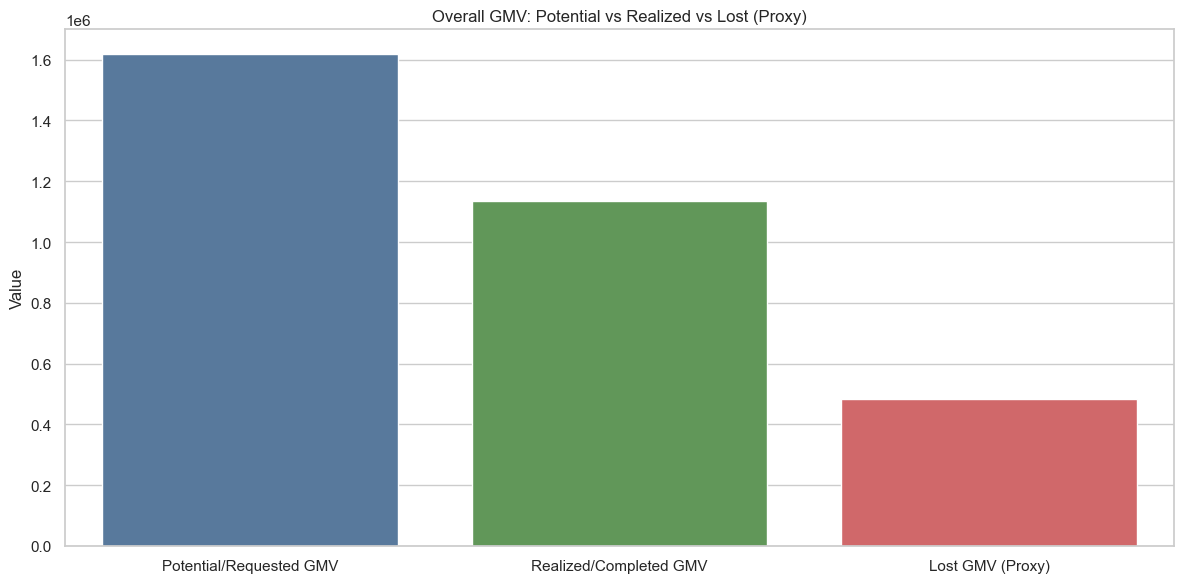

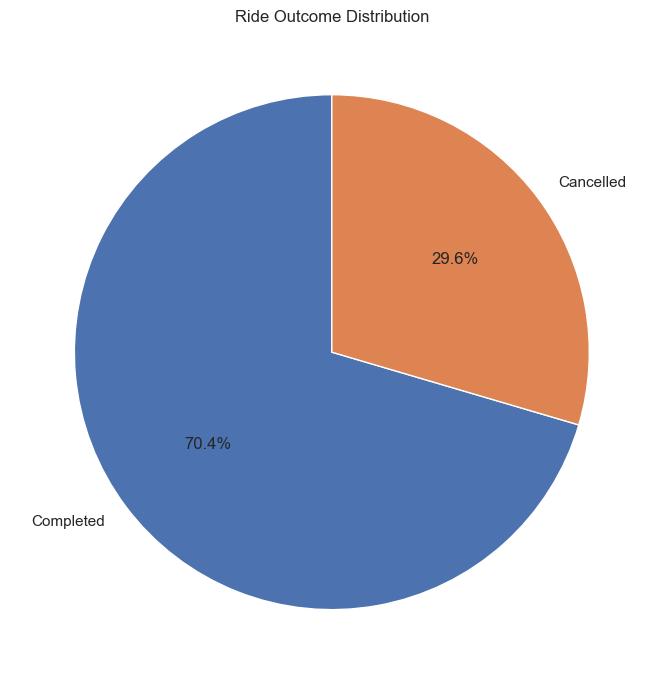

C:\Users\HP\AppData\Local\Temp\ipykernel_26612\3744710721.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


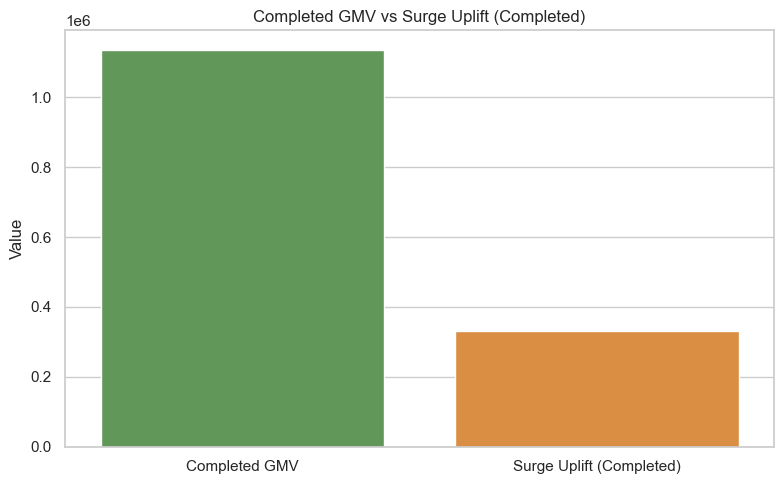

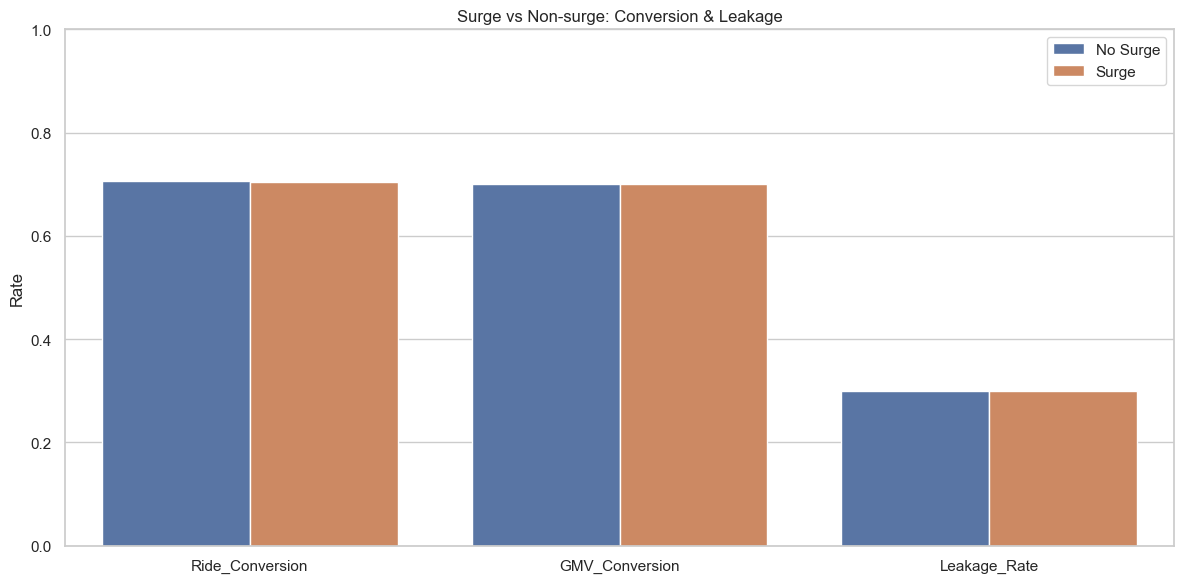

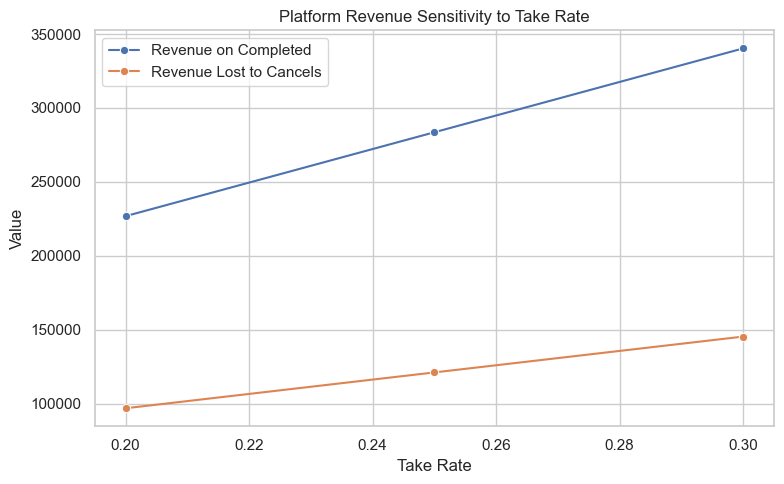

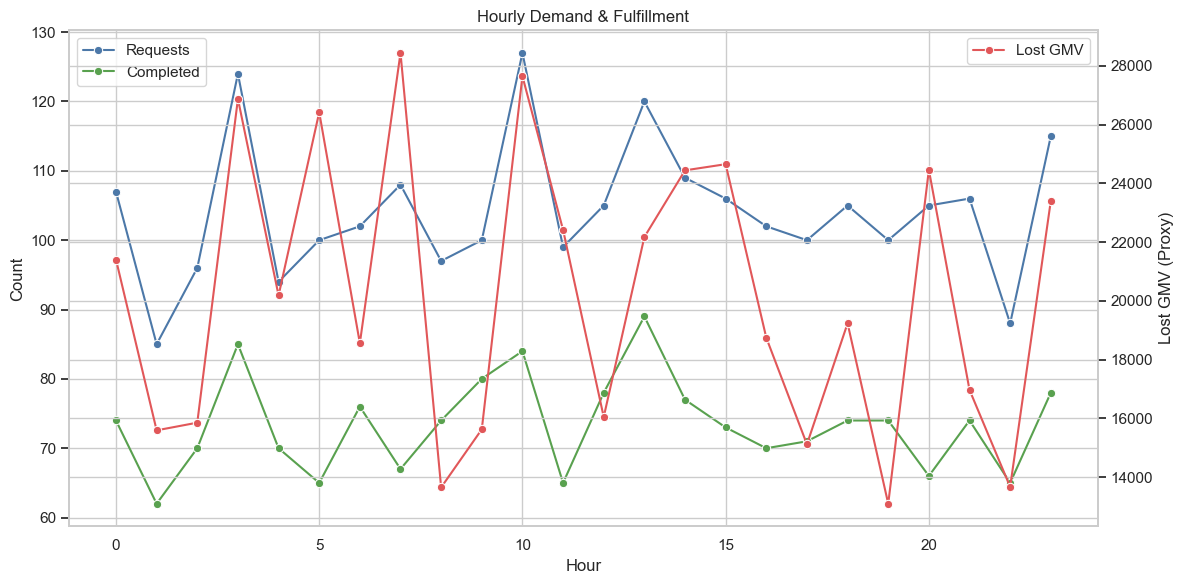

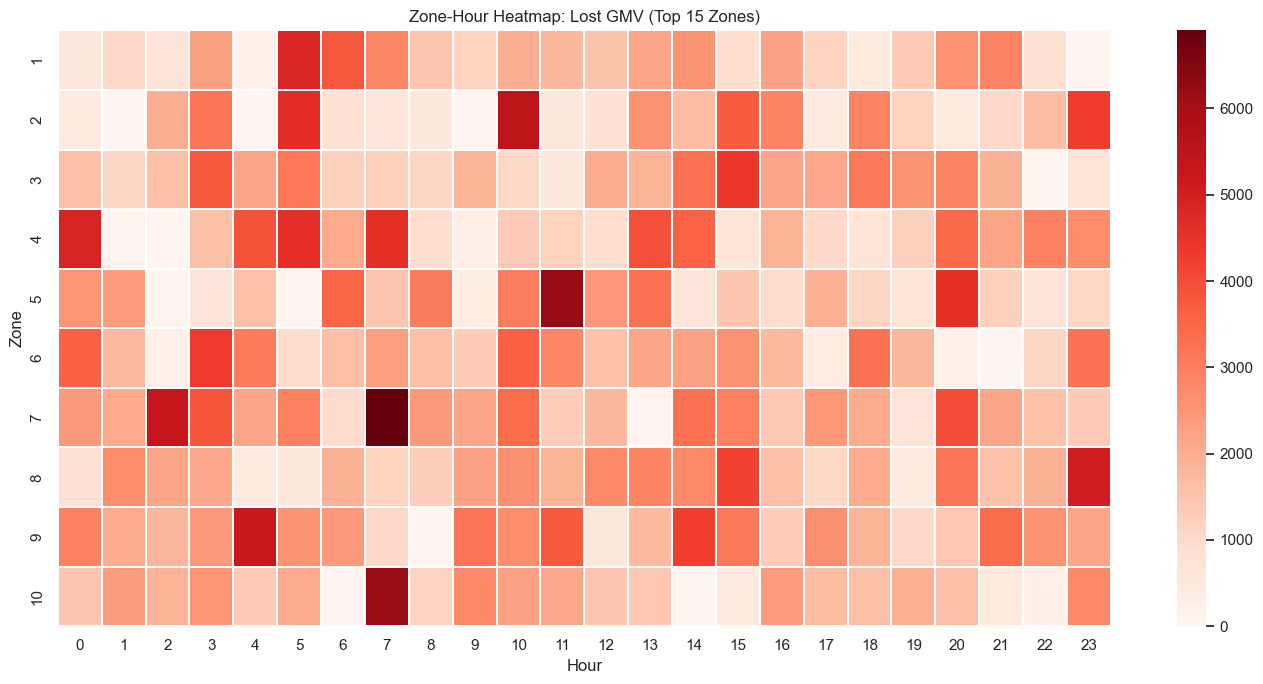

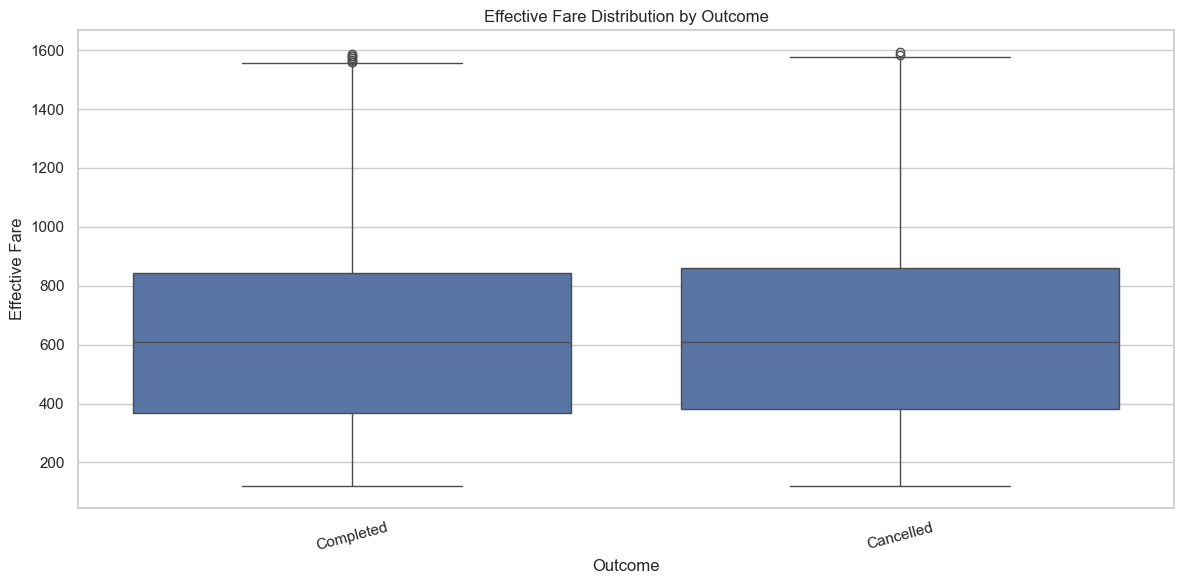

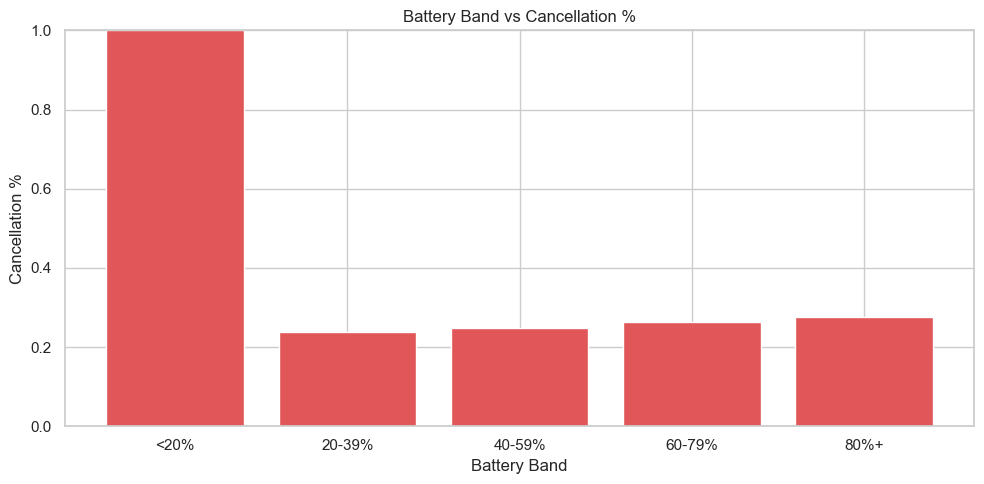

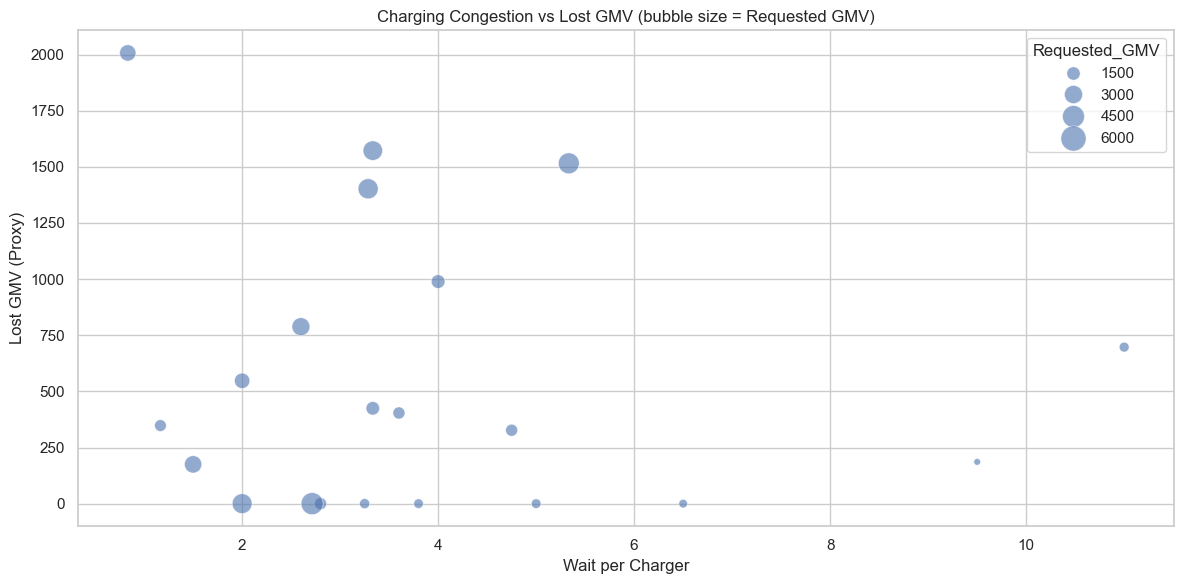


Done: all financial metrics + charts generated .


In [12]:
# ============================================================
# Battery plot uses matplotlib to avoid seaborn categorical hashing
# ============================================================

plt.rcParams["figure.figsize"] = (12, 6)

# 1) Overall GMV bar chart
gmv_plot = pd.DataFrame({
    "Type": ["Potential/Requested GMV", "Realized/Completed GMV", "Lost GMV (Proxy)"],
    "Value": [requested_gmv, completed_gmv, lost_gmv_proxy]
})
plt.figure()
sns.barplot(data=gmv_plot, x="Type", y="Value", palette=["#4c78a8", "#59a14f", "#e15759"])
plt.title("Overall GMV: Potential vs Realized vs Lost (Proxy)")
plt.ylabel("Value")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 2) Outcome distribution pie
outcome_counts = rides["outcome_norm"].value_counts(dropna=False)
plt.figure(figsize=(7, 7))
plt.pie(outcome_counts.values, labels=outcome_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Ride Outcome Distribution")
plt.tight_layout()
plt.show()

# 3) Completed GMV vs Surge Uplift
plt.figure(figsize=(8, 5))
sns.barplot(
    x=["Completed GMV", "Surge Uplift (Completed)"],
    y=[completed_gmv, surge_uplift_completed],
    palette=["#59a14f", "#f28e2b"]
)
plt.title("Completed GMV vs Surge Uplift (Completed)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# 4) Surge vs Non-surge conversion/leakage
surge_plot = surge_summary.copy()
surge_plot["Period"] = surge_plot["is_surge"].map({0: "No Surge", 1: "Surge"})
surge_melt = surge_plot.melt(
    id_vars=["Period"],
    value_vars=["Ride_Conversion", "GMV_Conversion", "Leakage_Rate"],
    var_name="Metric",
    value_name="Rate"
)
plt.figure()
sns.barplot(data=surge_melt, x="Metric", y="Rate", hue="Period")
plt.title("Surge vs Non-surge: Conversion & Leakage")
plt.ylabel("Rate")
plt.xlabel("")
plt.ylim(0, 1)
plt.legend(title="")
plt.tight_layout()
plt.show()

# 5) Platform revenue sensitivity
plt.figure(figsize=(8, 5))
sns.lineplot(data=platform_revenue, x="Take_Rate", y="Platform_Revenue_on_Completed", marker="o", label="Revenue on Completed")
sns.lineplot(data=platform_revenue, x="Take_Rate", y="Platform_Revenue_Lost_to_Cancels", marker="o", label="Revenue Lost to Cancels")
plt.title("Platform Revenue Sensitivity to Take Rate")
plt.ylabel("Value")
plt.xlabel("Take Rate")
plt.tight_layout()
plt.show()

# 6) Hourly trends (if hour exists)
if rides["hour_num"].notna().any():
    hourly = rides.groupby("hour_num").apply(
        lambda df: pd.Series({
            "Requests": len(df),
            "Completed_Rides": (df["outcome_norm"] == "Completed").sum(),
            "Requested_GMV": df["effective_fare"].sum(),
            "Completed_GMV": df.loc[df["outcome_norm"] == "Completed", "effective_fare"].sum(),
        })
    ).reset_index().sort_values("hour_num")

    hourly["Lost_GMV"] = hourly["Requested_GMV"] - hourly["Completed_GMV"]

    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=hourly, x="hour_num", y="Requests", marker="o", ax=ax1, label="Requests", color="#4c78a8")
    sns.lineplot(data=hourly, x="hour_num", y="Completed_Rides", marker="o", ax=ax1, label="Completed", color="#59a14f")
    ax1.set_title("Hourly Demand & Fulfillment")
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Count")
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    sns.lineplot(data=hourly, x="hour_num", y="Lost_GMV", marker="o", ax=ax2, label="Lost GMV", color="#e15759")
    ax2.set_ylabel("Lost GMV (Proxy)")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# 7) Heatmap: Zone-hour Lost GMV (if zone/hour exist)
if zone_hour_fin is not None and col_zone is not None and "hour_num" in zone_hour_fin.columns:
    top_zones = (
        zone_hour_fin.groupby(col_zone, dropna=False)["Requested_GMV"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .index
    )
    hm_df = zone_hour_fin[zone_hour_fin[col_zone].isin(top_zones)].copy()
    pivot_lost = hm_df.pivot_table(index=col_zone, columns="hour_num", values="Lost_GMV", aggfunc="sum")

    plt.figure(figsize=(14, 7))
    sns.heatmap(pivot_lost, cmap="Reds", linewidths=0.3)
    plt.title("Zone-Hour Heatmap: Lost GMV (Top 15 Zones)")
    plt.xlabel("Hour")
    plt.ylabel("Zone")
    plt.tight_layout()
    plt.show()

# 8) Scatter: Drivers Online vs Leakage (if drivers_online exists)
if zone_hour_fin is not None and zone_hour_fin["Avg_Drivers_Online"].notna().any():
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=zone_hour_fin,
        x="Avg_Drivers_Online",
        y="GMV_Leakage_Rate",
        size="Requested_GMV",
        sizes=(20, 400),
        alpha=0.6
    )
    plt.title("Supply vs Leakage: Avg Drivers Online vs GMV Leakage Rate")
    plt.xlabel("Avg Drivers Online")
    plt.ylabel("GMV Leakage Rate")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# 9) Boxplot: Effective fare distribution by outcome
plt.figure(figsize=(12, 6))
sns.boxplot(data=rides, x="outcome_norm", y="effective_fare")
plt.title("Effective Fare Distribution by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Effective Fare")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 10) Battery band vs Cancellation % (matplotlib to avoid ndarray-hash crash)
if batt_fin is not None and "Cancel_%" in batt_fin.columns and len(batt_fin) > 0:
    # Convert to plain python scalars (guaranteed safe)
    tmp = batt_fin.copy()
    tmp["battery_band"] = force_hashable_series(tmp["battery_band"]).astype(str)

    band_to_cancel = {band: float(val) for band, val in zip(tmp["battery_band"], tmp["Cancel_%"])}
    x_labels = [b for b in BATTERY_ORDER if b in band_to_cancel]
    y_vals = [band_to_cancel[b] for b in x_labels]

    plt.figure(figsize=(10, 5))
    plt.bar(x_labels, y_vals, color="#e15759")
    plt.title("Battery Band vs Cancellation %")
    plt.xlabel("Battery Band")
    plt.ylabel("Cancellation %")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# 11) Charging congestion vs Lost GMV (if merged hotspots exist)
if merged_hotspots is not None and "Wait_per_Charger" in merged_hotspots.columns and merged_hotspots["Wait_per_Charger"].notna().any():
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=merged_hotspots,
        x="Wait_per_Charger",
        y="Lost_GMV",
        size="Requested_GMV",
        sizes=(20, 400),
        alpha=0.6
    )
    plt.title("Charging Congestion vs Lost GMV (bubble size = Requested GMV)")
    plt.xlabel("Wait per Charger")
    plt.ylabel("Lost GMV (Proxy)")
    plt.tight_layout()
    plt.show()

print("\nDone: all financial metrics + charts generated .")